STEP 4: DEEP SEQUENCE MODELS
Mounted at /content/drive

Google Drive mounted successfully.

TensorFlow version: 2.20.0
GPU devices detected: 0

The code will still run, but training may take longer.

TensorFlow deterministic operations enabled.

Input daily profile:
/content/drive/MyDrive/Load_Forecasting_Paper/data/forecasting/daily_23slot_load_profile_raw.csv

Forecast-sample file:
/content/drive/MyDrive/Load_Forecasting_Paper/data/forecasting/forecasting_samples_23slot.csv

Daily profile loaded.
Rows: 3979
Period: 2015-04-17 00:00:00 to 2026-03-08 00:00:00

Complete calendar days: 3979

Original observed cells: 90419
Original missing cells: 1098

Performing causal historical-input imputation...
Causal imputation completed.

HISTORICAL INPUT IMPUTATION REPORT


,source_code,source,cells,percent
0,0,Still missing,36,0.0393
1,1,Observed,90419,98.8002
2,2,Causal lag-7 fill,1035,1.1309
3,3,Causal lag-1 fill,27,0.0295
4,4,Past-28-day median fill,0,0.0000



Remaining missing historical cells: 36

Forecast samples loaded: 3218

Sequence length: 28 calendar days

REAL SEQUENCE DATASET CREATED
Sequence samples: 3216
Load input shape: (3216, 28, 23)
Observation-mask shape: (3216, 28, 23)
Calendar-input shape: (3216, 8)
Target shape: (3216, 23)

Skipped because < 28 prior days: 2
Skipped because causal historical data remained missing: 0

SEQUENCE DATA SPLITS
TRAIN: 2234
VALIDATION: 273
TEST-A 2024: 298
TEST-B 2025-2026: 411
ALL TEST: 709

Training target normalization statistics created.

Final neural sequence input shape: (3216, 28, 46)
Features per historical day: 46

Training D1 MASE scale: 512.0877 MW

DEEP-MODEL VALIDATION STAGE


--------------------------------------------------------------------------------------------------------------
TRAINING: LSTM
--------------------------------------------------------------------------------------------------------------

Parameter count: 125175
Epoch 1/150
70/70 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/st

,model,best_epoch,epochs_executed,parameters,training_seconds,MAE_MW,RMSE_MW,MAPE_percent,sMAPE_percent,MASE
0,LSTM,32,47,125175,144.7063,437.8633,665.1604,4.1218,4.0340,0.8551
1,GRU,12,27,103159,85.6833,446.5124,673.3268,4.2311,4.1352,0.8719
2,Transformer,32,47,99383,266.0336,483.1136,741.2242,4.5013,4.3732,0.9434
3,TemporalCNN,76,91,100247,137.3108,709.2619,969.5790,6.7718,6.6388,1.3850



Selected architecture based ONLY on validation MAE:
LSTM

Validation Seasonal Naive D1:
MAE: 629.667 MW

FINAL DEEP-MODEL TRAINING STAGE
TRAIN + VALIDATION samples: 2507
Final TEST samples: 709


--------------------------------------------------------------------------------------------------------------
FINAL FIT: LSTM
Fixed epochs from validation: 32
--------------------------------------------------------------------------------------------------------------
Saved: /content/drive/MyDrive/Load_Forecasting_Paper/models/deep_sequence/LSTM_final.keras


--------------------------------------------------------------------------------------------------------------
FINAL FIT: GRU
Fixed epochs from validation: 12
--------------------------------------------------------------------------------------------------------------
Saved: /content/drive/MyDrive/Load_Forecasting_Paper/models/deep_sequence/GRU_final.keras


-----------------------------------------------------------------------------

,split,model,samples,MAE_MW,RMSE_MW,MAPE_percent,sMAPE_percent,MASE,MAE_skill_vs_D1_percent,selected_deep_architecture
0,ALL_TEST_2024_2026,Ridge,709,437.1586,648.5694,3.7785,3.7285,0.8537,32.6623,False
1,ALL_TEST_2024_2026,GRU,709,495.4432,692.0164,4.2557,4.2505,0.9675,23.6844,False
2,ALL_TEST_2024_2026,LSTM,709,503.5397,682.3879,4.3052,4.3100,0.9833,22.4372,True
3,ALL_TEST_2024_2026,ExtraTrees,709,556.0930,766.5503,4.7597,4.7902,1.0859,14.3422,False
4,ALL_TEST_2024_2026,XGBoost,709,594.4142,830.7135,4.8903,4.9842,1.1608,8.4394,False
5,ALL_TEST_2024_2026,Seasonal_Naive_D1,709,649.2030,954.2540,5.8463,5.7875,1.2678,0.0000,False
6,ALL_TEST_2024_2026,Transformer,709,667.7174,911.3178,5.4305,5.5740,1.3039,-2.8519,False
7,ALL_TEST_2024_2026,TemporalCNN,709,918.9969,1196.0950,7.6897,7.8523,1.7946,-41.5577,False
8,ALL_TEST_2024_2026,Seasonal_Naive_D7,709,1071.6673,1573.6499,9.2371,9.0812,2.0927,-65.0743,False
9,TEST_A_2024,Ridge,298,463.2735,690.6035,4.1026,4.0265,0.9047,32.8854,False



VALIDATION-SELECTED DEEP MODEL ON TEST
Selected model: LSTM
Test MAE: 503.54 MW
Test RMSE: 682.388 MW
Test MAPE: 4.305 %
Test sMAPE: 4.31 %
Test skill vs D1: 22.437 %

Ridge MAE: 437.159 MW
Selected deep-model MAE skill vs Ridge: -15.185 %

PROFILE / PEAK UTILITY METRICS


,split,model,Peak_Magnitude_MAE_MW,Peak_Hour_Exact_Accuracy_percent,Peak_Hour_Within_1h_Accuracy_percent,Mean_Peak_Hour_Error_hours,Daily_Profile_Sum_MAE_MWh_proxy
0,TEST_A_2024,Seasonal_Naive_D1,582.2550,48.6577,66.1074,4.0168,12931.1342
1,TEST_A_2024,Seasonal_Naive_D7,1154.4027,46.9799,70.1342,4.0772,28336.5503
2,TEST_A_2024,Ridge,521.2786,47.9866,68.7919,3.3758,9154.2151
3,TEST_A_2024,ExtraTrees,610.0772,43.6242,72.8188,3.1812,10265.2392
4,TEST_A_2024,XGBoost,665.7294,50.3356,73.4899,3.3691,11374.2320
5,TEST_A_2024,LSTM,518.7178,41.9463,73.1544,2.8859,9648.2955
6,TEST_A_2024,GRU,494.5813,48.9933,70.1342,2.8993,9448.2283
7,TEST_A_2024,TemporalCNN,1113.4481,49.3289,72.8188,2.8725,22339.3996
8,TEST_A_2024,Transformer,709.5156,47.3154,71.8121,3.0570,13900.8869
9,TEST_B_2025_2026,Seasonal_Naive_D1,507.5061,43.3090,59.6107,4.1387,11077.3309


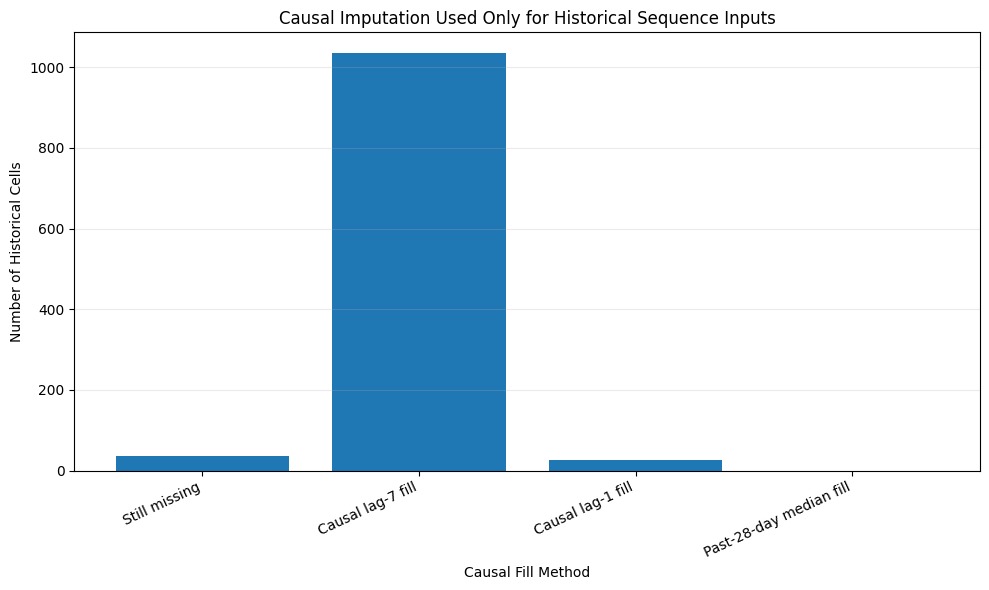

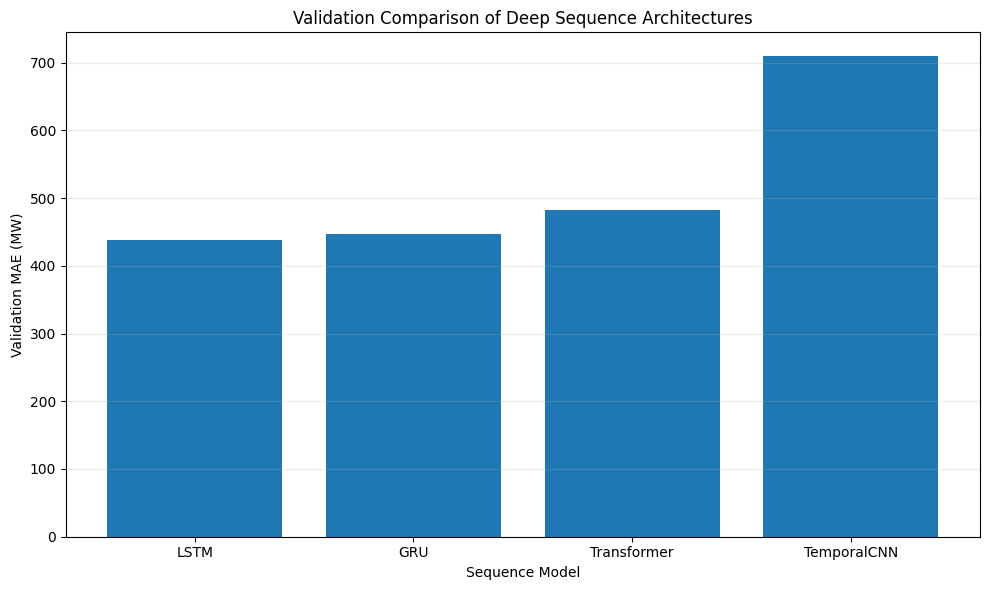

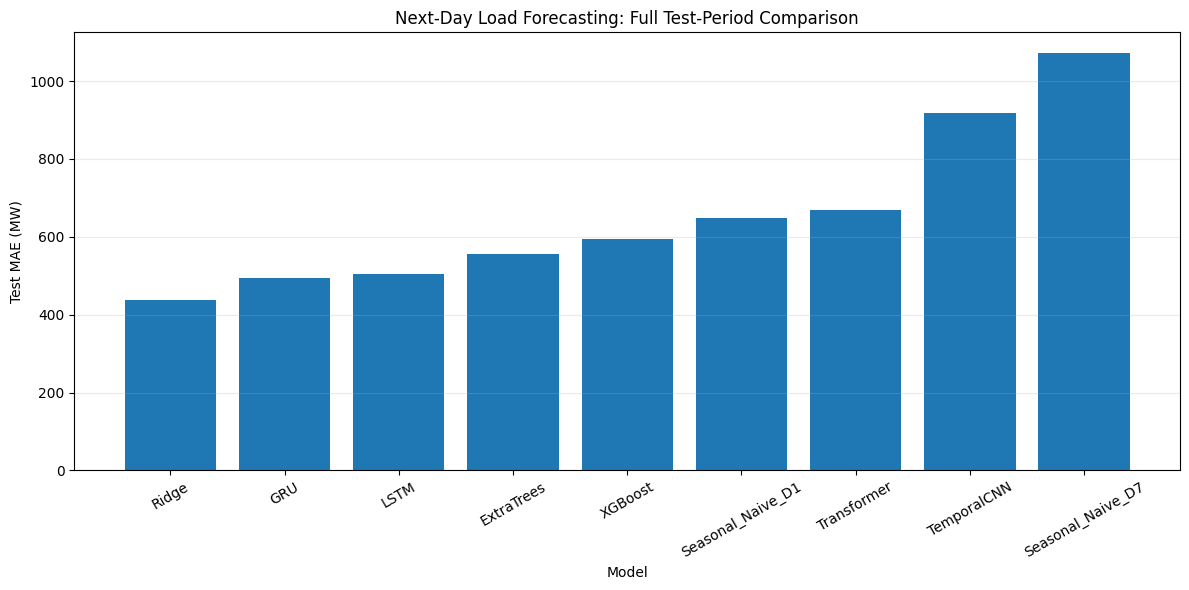

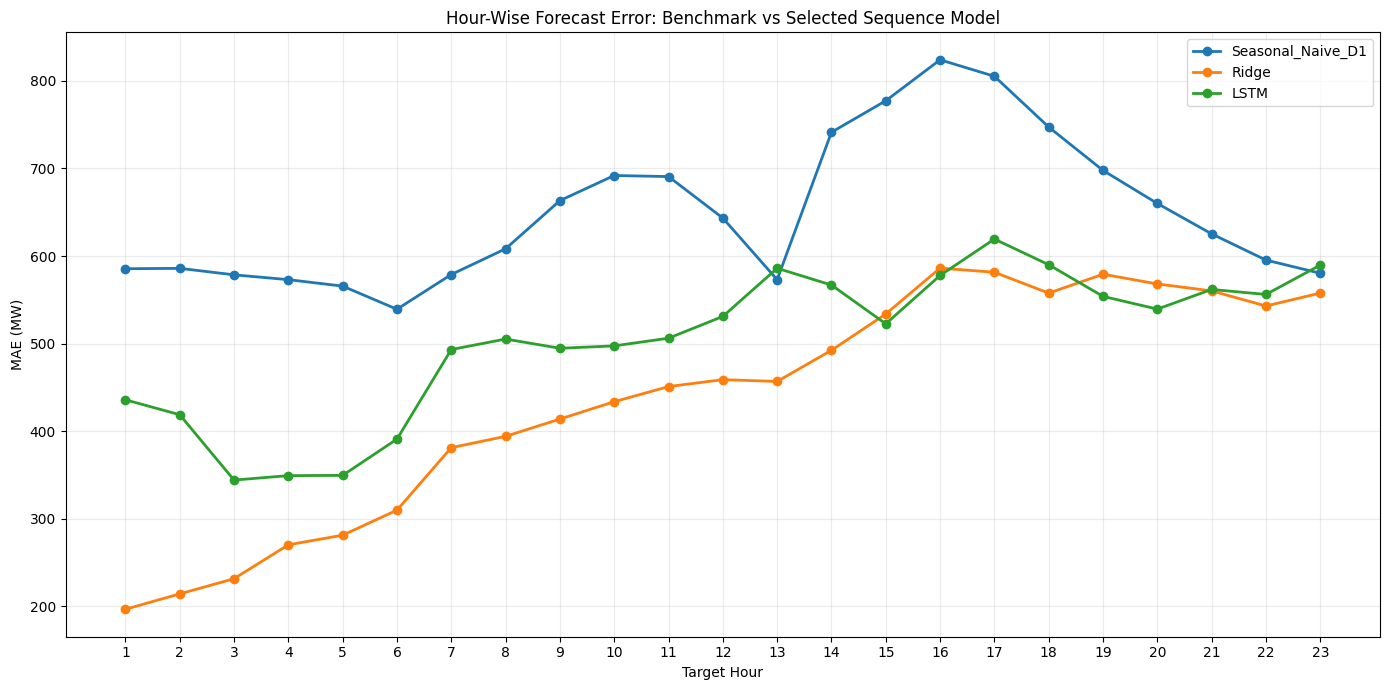

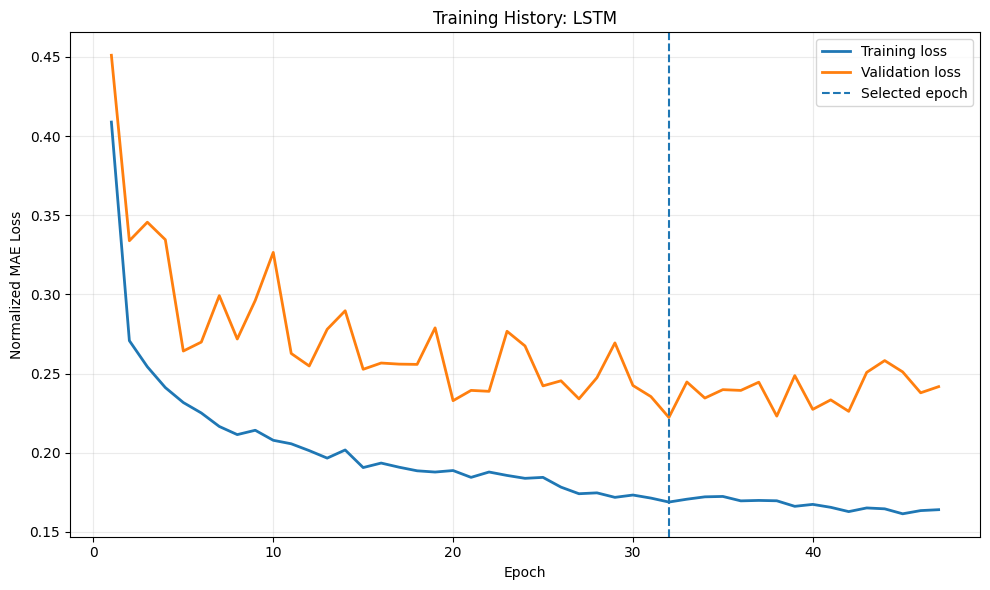

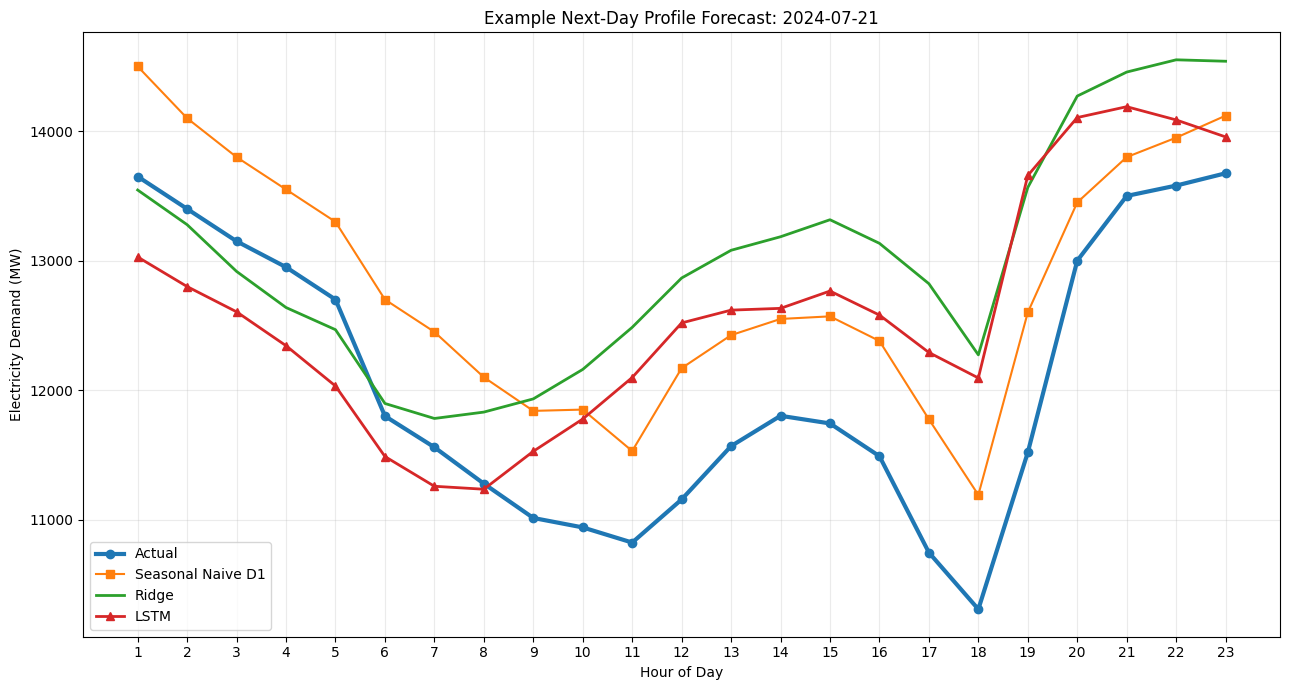


All Step 4 validation checks PASSED.


STEP 4 COMPLETED SUCCESSFULLY

Sequence input: 28 days × 23 load slots
Neural input channels/day: 46

TRAIN samples: 2234
VALIDATION samples: 273
TEST-A 2024 samples: 298
TEST-B 2025-2026 samples: 411

--------------------------------------------------------------------------------------------------------------
VALIDATION-SELECTED DEEP ARCHITECTURE
--------------------------------------------------------------------------------------------------------------
Model: LSTM
Best epoch: 32
Validation MAE: 437.863 MW
Validation MAPE: 4.122 %

--------------------------------------------------------------------------------------------------------------
SELECTED DEEP MODEL — ALL TEST DATA
--------------------------------------------------------------------------------------------------------------
MAE: 503.54 MW
RMSE: 682.388 MW
MAPE: 4.305 %
sMAPE: 4.31 %
MASE: 0.9833
MAE skill vs Naive D1: 22.437 %

Ridge reference MAE: 437.159 MW
Deep-model skill vs Ri

In [ ]:
# =====================================================================
# STEP 4
# DEEP SEQUENCE MODELS FOR NEXT-DAY 23-SLOT LOAD FORECASTING
#
# Models:
#   1. LSTM
#   2. GRU
#   3. Temporal CNN
#   4. Transformer Encoder
#
# Input:
#   Previous 28 calendar days
#   Each day = 23 national electricity-demand values
#
# Additional input:
#   Observed/imputed mask + known target-day calendar features
#
# Output:
#   Next day 01:00-23:00 demand profile = 23 values
#
# Methodology:
#   TRAIN      = through 2022
#   VALIDATION = 2023
#   TEST-A     = 2024
#   TEST-B     = 2025-Mar 2026
#
# Architecture selection is based ONLY on VALIDATION.
# Test data is untouched until final evaluation.
#
# Run this entire code in ONE Google Colab cell.
# =====================================================================


# =====================================================================
# 0. IMPORT LIBRARIES
# =====================================================================

import os
import sys
import gc
import json
import math
import time
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 260)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


print("=" * 110)
print("STEP 4: DEEP SEQUENCE MODELS")
print("=" * 110)


# =====================================================================
# 1. MOUNT GOOGLE DRIVE
# =====================================================================

from google.colab import drive

drive.mount("/content/drive")

print("\nGoogle Drive mounted successfully.")


# =====================================================================
# 2. IMPORT TENSORFLOW
# =====================================================================

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


tf.keras.utils.set_random_seed(SEED)


print("\nTensorFlow version:", tf.__version__)


gpu_devices = tf.config.list_physical_devices("GPU")

print("GPU devices detected:", len(gpu_devices))

if len(gpu_devices) > 0:

    for device in gpu_devices:
        print(" -", device)

else:

    print(
        "\nWARNING: No GPU detected."
    )

    print(
        "The code will still run, but training may take longer."
    )


# =====================================================================
# 3. TRY TO ENABLE DETERMINISTIC OPERATIONS
# =====================================================================

try:

    tf.config.experimental.enable_op_determinism()

    print(
        "\nTensorFlow deterministic operations enabled."
    )

except Exception as error:

    print(
        "\nCould not explicitly enable deterministic operations:"
    )

    print(error)


# =====================================================================
# 4. PROJECT DIRECTORIES
# =====================================================================

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Load_Forecasting_Paper"
)


FORECAST_DIR = (
    PROJECT_ROOT
    / "data"
    / "forecasting"
)


STEP3_RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "ml_baselines"
)


MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "deep_sequence"
)


RESULT_DIR = (
    PROJECT_ROOT
    / "results"
    / "deep_sequence"
)


FIGURE_DIR = (
    PROJECT_ROOT
    / "figures"
    / "deep_sequence"
)


HISTORY_DIR = (
    RESULT_DIR
    / "training_histories"
)


for directory in [

    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    HISTORY_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 5. INPUT FILES
# =====================================================================

PROFILE_FILE = (
    FORECAST_DIR
    / "daily_23slot_load_profile_raw.csv"
)


SAMPLES_FILE = (
    FORECAST_DIR
    / "forecasting_samples_23slot.csv"
)


STEP3_PREDICTION_FILE = (
    STEP3_RESULT_DIR
    / "all_test_predictions.csv"
)


STEP3_LEADERBOARD_FILE = (
    STEP3_RESULT_DIR
    / "final_test_leaderboard.csv"
)


for required_file in [

    PROFILE_FILE,
    SAMPLES_FILE

]:

    if not required_file.exists():

        raise FileNotFoundError(
            f"""
Required Step 2 file was not found:

{required_file}

Run Step 2 successfully before Step 4.
"""
        )


print("\nInput daily profile:")
print(PROFILE_FILE)


print("\nForecast-sample file:")
print(SAMPLES_FILE)


# =====================================================================
# 6. LOAD DAILY PROFILE MATRIX
# =====================================================================

profile_df = pd.read_csv(
    PROFILE_FILE,
    low_memory=False
)


# Handle either possible date-column name.

if "target_date" in profile_df.columns:

    PROFILE_DATE_COLUMN = "target_date"

elif "date" in profile_df.columns:

    PROFILE_DATE_COLUMN = "date"

else:

    raise ValueError(
        "Could not locate the date column in daily profile file."
    )


profile_df[
    PROFILE_DATE_COLUMN
] = pd.to_datetime(

    profile_df[
        PROFILE_DATE_COLUMN
    ],

    errors="coerce"
)


profile_df = (

    profile_df
    .dropna(
        subset=[
            PROFILE_DATE_COLUMN
        ]
    )

    .sort_values(
        PROFILE_DATE_COLUMN
    )

    .reset_index(
        drop=True
    )
)


HOURS = list(
    range(
        1,
        24
    )
)


DEMAND_COLUMNS = [

    f"demand_h{hour:02d}"

    for hour in HOURS
]


missing_profile_columns = [

    column

    for column in DEMAND_COLUMNS

    if column not in profile_df.columns
]


if len(
    missing_profile_columns
) > 0:

    raise ValueError(
        f"""
Missing 23-slot demand columns:

{missing_profile_columns}
"""
    )


for column in DEMAND_COLUMNS:

    profile_df[column] = pd.to_numeric(
        profile_df[column],
        errors="coerce"
    )


print("\nDaily profile loaded.")

print(
    "Rows:",
    len(profile_df)
)

print(
    "Period:",
    profile_df[
        PROFILE_DATE_COLUMN
    ].min(),
    "to",
    profile_df[
        PROFILE_DATE_COLUMN
    ].max()
)


# =====================================================================
# 7. REINDEX PROFILE TO COMPLETE CALENDAR
# =====================================================================

profile_matrix_df = (

    profile_df
    .set_index(
        PROFILE_DATE_COLUMN
    )[
        DEMAND_COLUMNS
    ]

    .copy()
)


full_calendar = pd.date_range(

    start=
        profile_matrix_df.index.min(),

    end=
        profile_matrix_df.index.max(),

    freq="D"
)


profile_matrix_df = (
    profile_matrix_df
    .reindex(
        full_calendar
    )
)


profile_matrix_df.index.name = (
    "target_date"
)


print(
    "\nComplete calendar days:",
    len(
        profile_matrix_df
    )
)


# =====================================================================
# 8. ORIGINAL OBSERVATION MASK
# =====================================================================

# 1 = real observed PGCB value
# 0 = missing value that may later be filled for HISTORICAL INPUT only.


raw_profile = (
    profile_matrix_df
    .to_numpy(
        dtype=float
    )
)


observed_mask = (

    np.isfinite(
        raw_profile
    )

    .astype(
        np.float32
    )
)


print(
    "\nOriginal observed cells:",
    int(
        observed_mask.sum()
    )
)


print(
    "Original missing cells:",
    int(
        observed_mask.size
        -
        observed_mask.sum()
    )
)


# =====================================================================
# 9. CAUSAL HISTORICAL IMPUTATION
# =====================================================================

# IMPORTANT:
#
# This is ONLY for sequence INPUTS.
#
# We never create/impute target-day labels.
#
#
# Priority for a missing historical value:
#
# 1. Same hour 7 calendar days ago
# 2. Same hour 1 day ago
# 3. Median of previous 28 available values of the same hour
#
# Every source is strictly in the past.
#
# Therefore no future target leakage is introduced.


filled_profile = (
    raw_profile.copy()
)


# source codes:
#
# 1 = observed
# 2 = lag-7 causal fill
# 3 = lag-1 causal fill
# 4 = past-28-day median fill
# 0 = still missing


fill_source = np.zeros_like(
    filled_profile,
    dtype=np.int8
)


fill_source[
    np.isfinite(
        filled_profile
    )
] = 1


n_days = (
    filled_profile.shape[0]
)


n_hours = (
    filled_profile.shape[1]
)


print(
    "\nPerforming causal historical-input imputation..."
)


for day_index in range(
    n_days
):

    for hour_index in range(
        n_hours
    ):

        if np.isfinite(
            filled_profile[
                day_index,
                hour_index
            ]
        ):

            continue


        # -------------------------------------------------------------
        # Candidate 1:
        # Same hour one week earlier
        # -------------------------------------------------------------

        if (
            day_index >= 7
            and
            np.isfinite(
                filled_profile[
                    day_index - 7,
                    hour_index
                ]
            )
        ):

            filled_profile[
                day_index,
                hour_index
            ] = (

                filled_profile[
                    day_index - 7,
                    hour_index
                ]
            )


            fill_source[
                day_index,
                hour_index
            ] = 2


            continue


        # -------------------------------------------------------------
        # Candidate 2:
        # Previous calendar day
        # -------------------------------------------------------------

        if (
            day_index >= 1
            and
            np.isfinite(
                filled_profile[
                    day_index - 1,
                    hour_index
                ]
            )
        ):

            filled_profile[
                day_index,
                hour_index
            ] = (

                filled_profile[
                    day_index - 1,
                    hour_index
                ]
            )


            fill_source[
                day_index,
                hour_index
            ] = 3


            continue


        # -------------------------------------------------------------
        # Candidate 3:
        # Past-only 28-day same-hour median
        # -------------------------------------------------------------

        start_index = max(
            0,
            day_index - 28
        )


        historical_values = (

            filled_profile[
                start_index:day_index,
                hour_index
            ]
        )


        historical_values = (

            historical_values[
                np.isfinite(
                    historical_values
                )
            ]
        )


        if len(
            historical_values
        ) > 0:

            filled_profile[
                day_index,
                hour_index
            ] = np.median(
                historical_values
            )


            fill_source[
                day_index,
                hour_index
            ] = 4


print(
    "Causal imputation completed."
)


# =====================================================================
# 10. IMPUTATION REPORT
# =====================================================================

fill_source_labels = {

    0:
        "Still missing",

    1:
        "Observed",

    2:
        "Causal lag-7 fill",

    3:
        "Causal lag-1 fill",

    4:
        "Past-28-day median fill"
}


imputation_rows = []


for source_code, source_name in (
    fill_source_labels.items()
):

    count = int(
        np.sum(
            fill_source
            ==
            source_code
        )
    )


    imputation_rows.append(
        {

            "source_code":
                source_code,

            "source":
                source_name,

            "cells":
                count,

            "percent":
                100
                *
                count
                /
                fill_source.size
        }
    )


imputation_report = pd.DataFrame(
    imputation_rows
)


print("\n" + "=" * 110)

print(
    "HISTORICAL INPUT IMPUTATION REPORT"
)

print("=" * 110)


display(
    imputation_report.round(4)
)


remaining_missing = int(

    np.isnan(
        filled_profile
    )
    .sum()
)


print(
    "\nRemaining missing historical cells:",
    remaining_missing
)


# =====================================================================
# 11. LOAD STEP 2 FORECAST SAMPLES
# =====================================================================

samples_df = pd.read_csv(
    SAMPLES_FILE,
    low_memory=False
)


samples_df[
    "target_date"
] = pd.to_datetime(

    samples_df[
        "target_date"
    ],

    errors="coerce"
)


samples_df = (

    samples_df
    .dropna(
        subset=[
            "target_date"
        ]
    )

    .sort_values(
        "target_date"
    )

    .reset_index(
        drop=True
    )
)


TARGET_COLUMNS = [

    f"target_h{hour:02d}"

    for hour in HOURS
]


LAG1_COLUMNS = [

    f"lag1_h{hour:02d}"

    for hour in HOURS
]


LAG7_COLUMNS = [

    f"lag7_h{hour:02d}"

    for hour in HOURS
]


for column in (

    TARGET_COLUMNS
    +
    LAG1_COLUMNS
    +
    LAG7_COLUMNS

):

    if column not in samples_df.columns:

        raise ValueError(
            f"Required forecasting column missing: {column}"
        )


print(
    "\nForecast samples loaded:",
    len(
        samples_df
    )
)


# =====================================================================
# 12. DATE POSITION LOOKUP
# =====================================================================

profile_dates = (
    profile_matrix_df.index
)


date_to_position = {

    date:
        index

    for index, date
    in enumerate(
        profile_dates
    )
}


# =====================================================================
# 13. SEQUENCE CONFIGURATION
# =====================================================================

SEQUENCE_LENGTH = 28


print(
    "\nSequence length:",
    SEQUENCE_LENGTH,
    "calendar days"
)


# =====================================================================
# 14. TARGET-DAY CALENDAR FEATURES
# =====================================================================

# These variables are known before the target day begins.


def create_calendar_vector(
    date
):

    date = pd.Timestamp(
        date
    )


    day_of_week = (
        date.dayofweek
    )


    month = (
        date.month
    )


    day_of_year = (
        date.dayofyear
    )


    # Known deterministic long-term time index.
    # Approximately 0 at 2015 and ~1.1 by 2026.

    trend = (

        (
            date
            -
            pd.Timestamp(
                "2015-01-01"
            )
        )
        .days

        /
        365.25

        /
        10.0
    )


    is_weekend = (

        1.0

        if day_of_week
        in
        [
            4,
            5
        ]

        else 0.0
    )


    return np.array(
        [

            np.sin(
                2
                *
                np.pi
                *
                day_of_week
                /
                7
            ),

            np.cos(
                2
                *
                np.pi
                *
                day_of_week
                /
                7
            ),

            np.sin(
                2
                *
                np.pi
                *
                month
                /
                12
            ),

            np.cos(
                2
                *
                np.pi
                *
                month
                /
                12
            ),

            np.sin(
                2
                *
                np.pi
                *
                day_of_year
                /
                365.25
            ),

            np.cos(
                2
                *
                np.pi
                *
                day_of_year
                /
                365.25
            ),

            is_weekend,

            trend
        ],

        dtype=np.float32
    )


CALENDAR_FEATURE_NAMES = [

    "dow_sin",
    "dow_cos",

    "month_sin",
    "month_cos",

    "doy_sin",
    "doy_cos",

    "is_weekend",

    "time_trend"
]


CALENDAR_DIM = len(
    CALENDAR_FEATURE_NAMES
)


# =====================================================================
# 15. BUILD REAL SEQUENCE SAMPLES
# =====================================================================

X_LOAD_RAW = []

X_MASK = []

X_CALENDAR = []

Y_RAW = []

NAIVE_D1_RAW = []

NAIVE_D7_RAW = []

SEQUENCE_DATES = []

SEQUENCE_SPLITS = []

SKIPPED_TOO_EARLY = 0

SKIPPED_MISSING_HISTORY = 0


for row_index, row in (
    samples_df.iterrows()
):

    target_date = pd.Timestamp(
        row[
            "target_date"
        ]
    )


    if target_date not in date_to_position:

        continue


    target_position = (
        date_to_position[
            target_date
        ]
    )


    # Need exactly 28 previous calendar days.

    if (
        target_position
        <
        SEQUENCE_LENGTH
    ):

        SKIPPED_TOO_EARLY += 1

        continue


    history_start = (

        target_position

        -
        SEQUENCE_LENGTH
    )


    history_end = (
        target_position
    )


    historical_load = (

        filled_profile[
            history_start:history_end,
            :
        ]

        .copy()
    )


    historical_mask = (

        observed_mask[
            history_start:history_end,
            :
        ]

        .copy()
    )


    # We never fill with future/global information.
    # If some very early values remain unavailable,
    # simply discard that sample.

    if not np.isfinite(
        historical_load
    ).all():

        SKIPPED_MISSING_HISTORY += 1

        continue


    target_values = (

        row[
            TARGET_COLUMNS
        ]

        .to_numpy(
            dtype=np.float32
        )
    )


    if not np.isfinite(
        target_values
    ).all():

        continue


    d1_values = (

        row[
            LAG1_COLUMNS
        ]

        .to_numpy(
            dtype=np.float32
        )
    )


    d7_values = (

        row[
            LAG7_COLUMNS
        ]

        .to_numpy(
            dtype=np.float32
        )
    )


    X_LOAD_RAW.append(
        historical_load
    )


    X_MASK.append(
        historical_mask
    )


    X_CALENDAR.append(
        create_calendar_vector(
            target_date
        )
    )


    Y_RAW.append(
        target_values
    )


    NAIVE_D1_RAW.append(
        d1_values
    )


    NAIVE_D7_RAW.append(
        d7_values
    )


    SEQUENCE_DATES.append(
        target_date
    )


    SEQUENCE_SPLITS.append(
        row[
            "split"
        ]
    )


X_LOAD_RAW = np.asarray(
    X_LOAD_RAW,
    dtype=np.float32
)


X_MASK = np.asarray(
    X_MASK,
    dtype=np.float32
)


X_CALENDAR = np.asarray(
    X_CALENDAR,
    dtype=np.float32
)


Y_RAW = np.asarray(
    Y_RAW,
    dtype=np.float32
)


NAIVE_D1_RAW = np.asarray(
    NAIVE_D1_RAW,
    dtype=np.float32
)


NAIVE_D7_RAW = np.asarray(
    NAIVE_D7_RAW,
    dtype=np.float32
)


SEQUENCE_DATES = pd.DatetimeIndex(
    SEQUENCE_DATES
)


SEQUENCE_SPLITS = np.asarray(
    SEQUENCE_SPLITS
)


print("\n" + "=" * 110)

print(
    "REAL SEQUENCE DATASET CREATED"
)

print("=" * 110)


print(
    "Sequence samples:",
    len(
        Y_RAW
    )
)


print(
    "Load input shape:",
    X_LOAD_RAW.shape
)


print(
    "Observation-mask shape:",
    X_MASK.shape
)


print(
    "Calendar-input shape:",
    X_CALENDAR.shape
)


print(
    "Target shape:",
    Y_RAW.shape
)


print(
    "\nSkipped because < 28 prior days:",
    SKIPPED_TOO_EARLY
)


print(
    "Skipped because causal historical data remained missing:",
    SKIPPED_MISSING_HISTORY
)


# =====================================================================
# 16. DEFINE TRAIN / VALIDATION / TEST MASKS
# =====================================================================

TRAIN_MASK = (
    SEQUENCE_SPLITS
    ==
    "TRAIN"
)


VALIDATION_MASK = (
    SEQUENCE_SPLITS
    ==
    "VALIDATION"
)


TEST_MASK = (
    SEQUENCE_SPLITS
    ==
    "TEST"
)


TEST_A_MASK = (

    TEST_MASK

    &

    (
        SEQUENCE_DATES.year
        ==
        2024
    )
)


TEST_B_MASK = (

    TEST_MASK

    &

    (
        SEQUENCE_DATES.year
        >=
        2025
    )
)


print("\n" + "=" * 110)

print(
    "SEQUENCE DATA SPLITS"
)

print("=" * 110)


print(
    "TRAIN:",
    int(
        TRAIN_MASK.sum()
    )
)


print(
    "VALIDATION:",
    int(
        VALIDATION_MASK.sum()
    )
)


print(
    "TEST-A 2024:",
    int(
        TEST_A_MASK.sum()
    )
)


print(
    "TEST-B 2025-2026:",
    int(
        TEST_B_MASK.sum()
    )
)


print(
    "ALL TEST:",
    int(
        TEST_MASK.sum()
    )
)


# =====================================================================
# 17. BASIC SPLIT VALIDATION
# =====================================================================

assert (
    TRAIN_MASK.sum()
    >
    0
)


assert (
    VALIDATION_MASK.sum()
    >
    0
)


assert (
    TEST_A_MASK.sum()
    >
    0
)


assert (
    TEST_B_MASK.sum()
    >
    0
)


# =====================================================================
# 18. PER-HOUR NORMALIZATION FROM TRAINING TARGETS ONLY
# =====================================================================

# Each hour has a different normal demand level.
#
# Therefore normalization is done separately for each of the 23 slots.
#
# Validation and test statistics are NOT used.


Y_TRAIN_RAW = (
    Y_RAW[
        TRAIN_MASK
    ]
)


hour_mean_train = (

    Y_TRAIN_RAW
    .mean(
        axis=0
    )
)


hour_std_train = (

    Y_TRAIN_RAW
    .std(
        axis=0
    )
)


hour_std_train = np.where(

    hour_std_train
    <
    1e-6,

    1.0,

    hour_std_train
)


print(
    "\nTraining target normalization statistics created."
)


# =====================================================================
# 19. NORMALIZATION FUNCTIONS
# =====================================================================

def normalize_load(
    values,
    means,
    stds
):

    return (

        values
        -
        means[
            None,
            None,
            :
        ]

    ) / (

        stds[
            None,
            None,
            :
        ]
    )


def normalize_targets(
    values,
    means,
    stds
):

    return (

        values
        -
        means[
            None,
            :
        ]

    ) / (

        stds[
            None,
            :
        ]
    )


def denormalize_targets(
    values,
    means,
    stds
):

    return (

        values
        *
        stds[
            None,
            :
        ]

        +
        means[
            None,
            :
        ]
    )


# =====================================================================
# 20. CREATE NORMALIZED SEQUENCE INPUT
# =====================================================================

normalized_load = normalize_load(

    X_LOAD_RAW,

    hour_mean_train,

    hour_std_train
)


# Concatenate:
#
# first 23 channels = normalized demand
# next 23 channels  = observed/imputed mask


X_SEQUENCE = np.concatenate(
    [
        normalized_load,
        X_MASK
    ],
    axis=-1
)


Y_NORMALIZED = normalize_targets(

    Y_RAW,

    hour_mean_train,

    hour_std_train
)


print(
    "\nFinal neural sequence input shape:",
    X_SEQUENCE.shape
)


print(
    "Features per historical day:",
    X_SEQUENCE.shape[-1]
)


# =====================================================================
# 21. SPLIT NEURAL ARRAYS
# =====================================================================

X_SEQ_TRAIN = (
    X_SEQUENCE[
        TRAIN_MASK
    ]
)


X_CAL_TRAIN = (
    X_CALENDAR[
        TRAIN_MASK
    ]
)


Y_TRAIN = (
    Y_NORMALIZED[
        TRAIN_MASK
    ]
)


X_SEQ_VAL = (
    X_SEQUENCE[
        VALIDATION_MASK
    ]
)


X_CAL_VAL = (
    X_CALENDAR[
        VALIDATION_MASK
    ]
)


Y_VAL = (
    Y_NORMALIZED[
        VALIDATION_MASK
    ]
)


Y_VAL_RAW = (
    Y_RAW[
        VALIDATION_MASK
    ]
)


X_SEQ_TEST = (
    X_SEQUENCE[
        TEST_MASK
    ]
)


X_CAL_TEST = (
    X_CALENDAR[
        TEST_MASK
    ]
)


Y_TEST_RAW = (
    Y_RAW[
        TEST_MASK
    ]
)


TEST_DATES = (
    SEQUENCE_DATES[
        TEST_MASK
    ]
)


# =====================================================================
# 22. METRIC FUNCTIONS
# =====================================================================

def mae(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    return float(

        np.mean(

            np.abs(
                y_true
                -
                y_pred
            )
        )
    )


def rmse(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    return float(

        np.sqrt(

            np.mean(

                (
                    y_true
                    -
                    y_pred
                )
                **
                2
            )
        )
    )


def mape(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    denominator = np.maximum(

        np.abs(
            y_true
        ),

        1e-6
    )


    return float(

        100

        *

        np.mean(

            np.abs(

                (
                    y_true
                    -
                    y_pred
                )

                /

                denominator
            )
        )
    )


def smape(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    denominator = (

        np.abs(
            y_true
        )

        +

        np.abs(
            y_pred
        )
    )


    valid = (
        denominator > 0
    )


    return float(

        100

        *

        np.mean(

            2

            *

            np.abs(

                y_true[
                    valid
                ]

                -

                y_pred[
                    valid
                ]
            )

            /

            denominator[
                valid
            ]
        )
    )


# =====================================================================
# 23. TRAINING MASE SCALE
# =====================================================================

NAIVE_D1_TRAIN_RAW = (

    NAIVE_D1_RAW[
        TRAIN_MASK
    ]
)


TRAIN_MASE_SCALE = mae(

    Y_RAW[
        TRAIN_MASK
    ],

    NAIVE_D1_TRAIN_RAW
)


print(
    "\nTraining D1 MASE scale:",
    round(
        TRAIN_MASE_SCALE,
        4
    ),
    "MW"
)


def metric_dict(
    y_true,
    y_pred
):

    model_mae = mae(
        y_true,
        y_pred
    )


    return {

        "MAE_MW":
            model_mae,

        "RMSE_MW":
            rmse(
                y_true,
                y_pred
            ),

        "MAPE_percent":
            mape(
                y_true,
                y_pred
            ),

        "sMAPE_percent":
            smape(
                y_true,
                y_pred
            ),

        "MASE":
            model_mae
            /
            TRAIN_MASE_SCALE
    }


# =====================================================================
# 24. FIXED SINUSOIDAL POSITIONAL ENCODING
# =====================================================================

def positional_encoding(
    sequence_length,
    embedding_dim
):

    positions = np.arange(
        sequence_length
    )[
        :,
        np.newaxis
    ]


    dimensions = np.arange(
        embedding_dim
    )[
        np.newaxis,
        :
    ]


    angle_rates = (

        1

        /

        np.power(

            10000,

            (
                2
                *
                (
                    dimensions
                    //
                    2
                )
            )

            /
            embedding_dim
        )
    )


    angle_radians = (

        positions

        *
        angle_rates
    )


    encoding = np.zeros(
        (
            sequence_length,
            embedding_dim
        ),
        dtype=np.float32
    )


    encoding[
        :,
        0::2
    ] = np.sin(
        angle_radians[
            :,
            0::2
        ]
    )


    encoding[
        :,
        1::2
    ] = np.cos(
        angle_radians[
            :,
            1::2
        ]
    )


    return (
        encoding[
            np.newaxis,
            :,
            :
        ]
    )


# =====================================================================
# 25. COMMON OUTPUT HEAD
# =====================================================================

def output_head(
    sequence_encoding,
    calendar_input
):

    x = layers.Concatenate()(
        [
            sequence_encoding,
            calendar_input
        ]
    )


    x = layers.Dense(
        128,
        activation="relu"
    )(
        x
    )


    x = layers.Dropout(
        0.20
    )(
        x
    )


    x = layers.Dense(
        64,
        activation="relu"
    )(
        x
    )


    output = layers.Dense(
        23,
        activation="linear",
        name="forecast"
    )(
        x
    )


    return output


# =====================================================================
# 26. BUILD LSTM MODEL
# =====================================================================

def build_lstm_model(
    sequence_shape,
    calendar_dim
):

    sequence_input = keras.Input(

        shape=sequence_shape,

        name="history_sequence"
    )


    calendar_input = keras.Input(

        shape=(
            calendar_dim,
        ),

        name="target_calendar"
    )


    x = layers.LSTM(

        128,

        dropout=0.10,

        recurrent_dropout=0.0,

        return_sequences=False
    )(
        sequence_input
    )


    x = layers.Dense(
        96,
        activation="relu"
    )(
        x
    )


    output = output_head(
        x,
        calendar_input
    )


    model = keras.Model(

        inputs=[
            sequence_input,
            calendar_input
        ],

        outputs=output,

        name="LSTM_28day"
    )


    return model


# =====================================================================
# 27. BUILD GRU MODEL
# =====================================================================

def build_gru_model(
    sequence_shape,
    calendar_dim
):

    sequence_input = keras.Input(

        shape=sequence_shape,

        name="history_sequence"
    )


    calendar_input = keras.Input(

        shape=(
            calendar_dim,
        ),

        name="target_calendar"
    )


    x = layers.GRU(

        128,

        dropout=0.10,

        recurrent_dropout=0.0,

        return_sequences=False
    )(
        sequence_input
    )


    x = layers.Dense(
        96,
        activation="relu"
    )(
        x
    )


    output = output_head(
        x,
        calendar_input
    )


    model = keras.Model(

        inputs=[
            sequence_input,
            calendar_input
        ],

        outputs=output,

        name="GRU_28day"
    )


    return model


# =====================================================================
# 28. BUILD TEMPORAL CNN MODEL
# =====================================================================

def build_cnn_model(
    sequence_shape,
    calendar_dim
):

    sequence_input = keras.Input(

        shape=sequence_shape,

        name="history_sequence"
    )


    calendar_input = keras.Input(

        shape=(
            calendar_dim,
        ),

        name="target_calendar"
    )


    x = layers.Conv1D(

        filters=64,

        kernel_size=3,

        padding="causal",

        activation="relu"
    )(
        sequence_input
    )


    x = layers.BatchNormalization()(
        x
    )


    x = layers.Conv1D(

        filters=96,

        kernel_size=3,

        padding="causal",

        activation="relu"
    )(
        x
    )


    x = layers.Dropout(
        0.15
    )(
        x
    )


    x = layers.Conv1D(

        filters=128,

        kernel_size=3,

        padding="causal",

        activation="relu"
    )(
        x
    )


    x = layers.GlobalAveragePooling1D()(
        x
    )


    x = layers.Dense(
        96,
        activation="relu"
    )(
        x
    )


    output = output_head(
        x,
        calendar_input
    )


    model = keras.Model(

        inputs=[
            sequence_input,
            calendar_input
        ],

        outputs=output,

        name="TemporalCNN_28day"
    )


    return model


# =====================================================================
# 29. TRANSFORMER BLOCK
# =====================================================================

def transformer_block(
    x,
    embedding_dim=64,
    num_heads=4,
    ff_dim=128,
    dropout_rate=0.10
):

    attention_output = (
        layers.MultiHeadAttention(

            num_heads=num_heads,

            key_dim=
                embedding_dim
                //
                num_heads,

            dropout=
                dropout_rate
        )(
            x,
            x
        )
    )


    attention_output = layers.Dropout(
        dropout_rate
    )(
        attention_output
    )


    x = layers.LayerNormalization(
        epsilon=1e-6
    )(
        x
        +
        attention_output
    )


    feed_forward = layers.Dense(

        ff_dim,

        activation="gelu"
    )(
        x
    )


    feed_forward = layers.Dropout(
        dropout_rate
    )(
        feed_forward
    )


    feed_forward = layers.Dense(

        embedding_dim

    )(
        feed_forward
    )


    feed_forward = layers.Dropout(
        dropout_rate
    )(
        feed_forward
    )


    x = layers.LayerNormalization(
        epsilon=1e-6
    )(
        x
        +
        feed_forward
    )


    return x


# =====================================================================
# 30. BUILD TRANSFORMER ENCODER MODEL
# =====================================================================

def build_transformer_model(
    sequence_shape,
    calendar_dim
):

    sequence_input = keras.Input(

        shape=sequence_shape,

        name="history_sequence"
    )


    calendar_input = keras.Input(

        shape=(
            calendar_dim,
        ),

        name="target_calendar"
    )


    EMBEDDING_DIM = 64


    x = layers.Dense(
        EMBEDDING_DIM
    )(
        sequence_input
    )


    pos_encoding = positional_encoding(

        SEQUENCE_LENGTH,

        EMBEDDING_DIM
    )


    # Add fixed positional information.

    x = layers.Lambda(

        lambda tensor:

            tensor

            +

            tf.constant(
                pos_encoding,
                dtype=tf.float32
            ),

        name="positional_encoding"
    )(
        x
    )


    x = transformer_block(

        x,

        embedding_dim=EMBEDDING_DIM,

        num_heads=4,

        ff_dim=128,

        dropout_rate=0.10
    )


    x = transformer_block(

        x,

        embedding_dim=EMBEDDING_DIM,

        num_heads=4,

        ff_dim=128,

        dropout_rate=0.10
    )


    x = layers.GlobalAveragePooling1D()(
        x
    )


    x = layers.Dense(
        96,
        activation="relu"
    )(
        x
    )


    output = output_head(
        x,
        calendar_input
    )


    model = keras.Model(

        inputs=[
            sequence_input,
            calendar_input
        ],

        outputs=output,

        name="TransformerEncoder_28day"
    )


    return model


# =====================================================================
# 31. MODEL FACTORY
# =====================================================================

MODEL_BUILDERS = {

    "LSTM":
        build_lstm_model,

    "GRU":
        build_gru_model,

    "TemporalCNN":
        build_cnn_model,

    "Transformer":
        build_transformer_model
}


# =====================================================================
# 32. COMPILATION FUNCTION
# =====================================================================

def compile_model(
    model
):

    optimizer = keras.optimizers.Adam(

        learning_rate=1e-3,

        clipnorm=1.0
    )


    model.compile(

        optimizer=optimizer,

        loss="mae",

        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            )
        ]
    )


    return model


# =====================================================================
# 33. CALLBACK FACTORY
# =====================================================================

def create_callbacks():

    early_stopping = (
        keras.callbacks.EarlyStopping(

            monitor="val_loss",

            mode="min",

            patience=15,

            min_delta=1e-4,

            restore_best_weights=True,

            verbose=1
        )
    )


    reduce_lr = (
        keras.callbacks.ReduceLROnPlateau(

            monitor="val_loss",

            mode="min",

            factor=0.5,

            patience=6,

            min_lr=1e-5,

            verbose=1
        )
    )


    return [
        early_stopping,
        reduce_lr
    ]


# =====================================================================
# 34. TRAIN ALL ARCHITECTURES ON TRAIN
#     SELECT USING VALIDATION ONLY
# =====================================================================

MAX_EPOCHS = 150

BATCH_SIZE = 32


validation_rows = []

training_histories = {}

best_epochs = {}


print("\n" + "=" * 110)

print(
    "DEEP-MODEL VALIDATION STAGE"
)

print("=" * 110)


for model_name, builder in (
    MODEL_BUILDERS.items()
):

    print("\n")
    print("-" * 110)

    print(
        "TRAINING:",
        model_name
    )

    print("-" * 110)


    tf.keras.backend.clear_session()

    gc.collect()


    tf.keras.utils.set_random_seed(
        SEED
    )


    model = builder(

        sequence_shape=
            X_SEQ_TRAIN.shape[1:],

        calendar_dim=
            CALENDAR_DIM
    )


    model = compile_model(
        model
    )


    print(
        "\nParameter count:",
        model.count_params()
    )


    start_time = time.time()


    history = model.fit(

        [
            X_SEQ_TRAIN,
            X_CAL_TRAIN
        ],

        Y_TRAIN,

        validation_data=(

            [
                X_SEQ_VAL,
                X_CAL_VAL
            ],

            Y_VAL
        ),

        epochs=
            MAX_EPOCHS,

        batch_size=
            BATCH_SIZE,

        callbacks=
            create_callbacks(),

        shuffle=True,

        verbose=1
    )


    training_seconds = (

        time.time()
        -
        start_time
    )


    validation_prediction_norm = (

        model.predict(

            [
                X_SEQ_VAL,
                X_CAL_VAL
            ],

            verbose=0
        )
    )


    validation_prediction = (

        denormalize_targets(

            validation_prediction_norm,

            hour_mean_train,

            hour_std_train
        )
    )


    metrics = metric_dict(

        Y_VAL_RAW,

        validation_prediction
    )


    val_losses = (

        history.history[
            "val_loss"
        ]
    )


    best_epoch = (

        int(
            np.argmin(
                val_losses
            )
        )

        +
        1
    )


    best_epochs[
        model_name
    ] = (
        best_epoch
    )


    history_df = pd.DataFrame(
        history.history
    )


    history_df[
        "epoch"
    ] = np.arange(
        1,
        len(
            history_df
        )
        +
        1
    )


    history_file = (

        HISTORY_DIR
        /
        f"{model_name}_validation_history.csv"
    )


    history_df.to_csv(
        history_file,
        index=False
    )


    training_histories[
        model_name
    ] = history_df


    validation_rows.append(
        {

            "model":
                model_name,

            "best_epoch":
                best_epoch,

            "epochs_executed":
                len(
                    history_df
                ),

            "parameters":
                int(
                    model.count_params()
                ),

            "training_seconds":
                training_seconds,

            **metrics
        }
    )


    print("\nValidation result:")

    print(
        " MAE:",
        round(
            metrics[
                "MAE_MW"
            ],
            3
        ),
        "MW"
    )


    print(
        " RMSE:",
        round(
            metrics[
                "RMSE_MW"
            ],
            3
        ),
        "MW"
    )


    print(
        " MAPE:",
        round(
            metrics[
                "MAPE_percent"
            ],
            3
        ),
        "%"
    )


    print(
        " Best epoch:",
        best_epoch
    )


    # Release validation-stage model.
    del model

    tf.keras.backend.clear_session()

    gc.collect()


# =====================================================================
# 35. VALIDATION DEEP-MODEL LEADERBOARD
# =====================================================================

deep_validation = pd.DataFrame(
    validation_rows
)


deep_validation = (

    deep_validation

    .sort_values(
        "MAE_MW"
    )

    .reset_index(
        drop=True
    )
)


SELECTED_DEEP_MODEL = (

    deep_validation
    .iloc[0][
        "model"
    ]
)


print("\n" + "=" * 110)

print(
    "DEEP-MODEL VALIDATION LEADERBOARD"
)

print("=" * 110)


display(
    deep_validation.round(4)
)


print(
    "\nSelected architecture based ONLY on validation MAE:"
)


print(
    SELECTED_DEEP_MODEL
)


# =====================================================================
# 36. VALIDATION BASELINE CHECK
# =====================================================================

val_naive_d1 = (

    NAIVE_D1_RAW[
        VALIDATION_MASK
    ]
)


val_naive_metrics = metric_dict(

    Y_VAL_RAW,

    val_naive_d1
)


print(
    "\nValidation Seasonal Naive D1:"
)


print(
    "MAE:",
    round(
        val_naive_metrics[
            "MAE_MW"
        ],
        3
    ),
    "MW"
)


# =====================================================================
# 37. PREPARE TRAIN + VALIDATION FOR FINAL MODEL FIT
# =====================================================================

TRAIN_VAL_MASK = (

    TRAIN_MASK

    |

    VALIDATION_MASK
)


Y_TRAIN_VAL_RAW = (
    Y_RAW[
        TRAIN_VAL_MASK
    ]
)


# Refit normalization statistics using TRAIN + VALIDATION
# after architecture selection.


hour_mean_train_val = (

    Y_TRAIN_VAL_RAW
    .mean(
        axis=0
    )
)


hour_std_train_val = (

    Y_TRAIN_VAL_RAW
    .std(
        axis=0
    )
)


hour_std_train_val = np.where(

    hour_std_train_val
    <
    1e-6,

    1.0,

    hour_std_train_val
)


# =====================================================================
# 38. RE-NORMALIZE ALL HISTORY USING TRAIN+VAL STATISTICS
# =====================================================================

normalized_load_tv = normalize_load(

    X_LOAD_RAW,

    hour_mean_train_val,

    hour_std_train_val
)


X_SEQUENCE_TV = np.concatenate(
    [
        normalized_load_tv,
        X_MASK
    ],
    axis=-1
)


Y_NORMALIZED_TV = normalize_targets(

    Y_RAW,

    hour_mean_train_val,

    hour_std_train_val
)


X_SEQ_TRAIN_VAL = (

    X_SEQUENCE_TV[
        TRAIN_VAL_MASK
    ]
)


X_CAL_TRAIN_VAL = (

    X_CALENDAR[
        TRAIN_VAL_MASK
    ]
)


Y_TRAIN_VAL = (

    Y_NORMALIZED_TV[
        TRAIN_VAL_MASK
    ]
)


X_SEQ_FINAL_TEST = (

    X_SEQUENCE_TV[
        TEST_MASK
    ]
)


X_CAL_FINAL_TEST = (

    X_CALENDAR[
        TEST_MASK
    ]
)


print("\n" + "=" * 110)

print(
    "FINAL DEEP-MODEL TRAINING STAGE"
)

print("=" * 110)


print(
    "TRAIN + VALIDATION samples:",
    len(
        Y_TRAIN_VAL
    )
)


print(
    "Final TEST samples:",
    len(
        Y_TEST_RAW
    )
)


# =====================================================================
# 39. FINAL FIT OF EACH ARCHITECTURE
#
# IMPORTANT:
# Number of epochs is already selected from validation.
#
# We do NOT use test data for early stopping.
# =====================================================================

deep_test_predictions = {}

final_model_information = []


for model_name, builder in (
    MODEL_BUILDERS.items()
):

    selected_epochs = int(
        best_epochs[
            model_name
        ]
    )


    # Avoid pathological case where minimum occurs extremely early.

    selected_epochs = max(
        selected_epochs,
        3
    )


    print("\n")
    print("-" * 110)

    print(
        f"FINAL FIT: {model_name}"
    )

    print(
        "Fixed epochs from validation:",
        selected_epochs
    )

    print("-" * 110)


    tf.keras.backend.clear_session()

    gc.collect()


    tf.keras.utils.set_random_seed(
        SEED
    )


    final_model = builder(

        sequence_shape=
            X_SEQ_TRAIN_VAL.shape[1:],

        calendar_dim=
            CALENDAR_DIM
    )


    final_model = compile_model(
        final_model
    )


    start_time = time.time()


    final_model.fit(

        [
            X_SEQ_TRAIN_VAL,
            X_CAL_TRAIN_VAL
        ],

        Y_TRAIN_VAL,

        epochs=
            selected_epochs,

        batch_size=
            BATCH_SIZE,

        shuffle=True,

        verbose=0
    )


    training_seconds = (

        time.time()
        -
        start_time
    )


    prediction_norm = (

        final_model.predict(

            [
                X_SEQ_FINAL_TEST,
                X_CAL_FINAL_TEST
            ],

            verbose=0
        )
    )


    prediction_raw = (

        denormalize_targets(

            prediction_norm,

            hour_mean_train_val,

            hour_std_train_val
        )
    )


    deep_test_predictions[
        model_name
    ] = (
        prediction_raw
    )


    model_file = (

        MODEL_DIR
        /
        f"{model_name}_final.keras"
    )


    final_model.save(
        model_file
    )


    final_model_information.append(
        {

            "model":
                model_name,

            "final_epochs":
                selected_epochs,

            "parameters":
                int(
                    final_model.count_params()
                ),

            "final_training_seconds":
                training_seconds,

            "model_file":
                str(
                    model_file
                )
        }
    )


    print(
        "Saved:",
        model_file
    )


    del final_model

    tf.keras.backend.clear_session()

    gc.collect()


# =====================================================================
# 40. SAVE NORMALIZATION PARAMETERS
# =====================================================================

NORMALIZATION_FILE = (

    RESULT_DIR
    /
    "deep_normalization_parameters.npz"
)


np.savez(

    NORMALIZATION_FILE,

    hour_mean_train=
        hour_mean_train,

    hour_std_train=
        hour_std_train,

    hour_mean_train_val=
        hour_mean_train_val,

    hour_std_train_val=
        hour_std_train_val
)


# =====================================================================
# 41. CREATE BASELINE PREDICTIONS ON SAME TEST DATES
# =====================================================================

NAIVE_D1_TEST = (

    NAIVE_D1_RAW[
        TEST_MASK
    ]
)


NAIVE_D7_TEST = (

    NAIVE_D7_RAW[
        TEST_MASK
    ]
)


all_predictions = {

    "Seasonal_Naive_D1":
        NAIVE_D1_TEST,

    "Seasonal_Naive_D7":
        NAIVE_D7_TEST
}


# =====================================================================
# 42. IMPORT STEP 3 MODEL PREDICTIONS
# =====================================================================

if STEP3_PREDICTION_FILE.exists():

    step3_pred = pd.read_csv(
        STEP3_PREDICTION_FILE,
        low_memory=False
    )


    step3_pred[
        "target_date"
    ] = pd.to_datetime(

        step3_pred[
            "target_date"
        ],

        errors="coerce"
    )


    step3_pred = (

        step3_pred
        .dropna(
            subset=[
                "target_date"
            ]
        )

        .drop_duplicates(
            subset=[
                "target_date"
            ]
        )

        .set_index(
            "target_date"
        )

        .reindex(
            TEST_DATES
        )
    )


    step3_model_prefixes = {

        "Ridge":
            "ridge",

        "ExtraTrees":
            "extratrees",

        "XGBoost":
            "xgboost"
    }


    for model_name, prefix in (
        step3_model_prefixes.items()
    ):

        prediction_columns = [

            f"{prefix}_pred_h{hour:02d}"

            for hour in HOURS
        ]


        if all(

            column
            in
            step3_pred.columns

            for column
            in prediction_columns
        ):

            prediction_matrix = (

                step3_pred[
                    prediction_columns
                ]

                .to_numpy(
                    dtype=float
                )
            )


            if np.isfinite(
                prediction_matrix
            ).all():

                all_predictions[
                    model_name
                ] = (
                    prediction_matrix
                )


    print(
        "\nStep 3 model predictions aligned successfully."
    )


else:

    print(
        "\nWARNING:"
    )

    print(
        "Step 3 prediction file not found."
    )

    print(
        "Deep models will still be compared with naive baselines."
    )


# Add deep models.

for model_name, prediction in (
    deep_test_predictions.items()
):

    all_predictions[
        model_name
    ] = (
        prediction
    )


# =====================================================================
# 43. TEST SUBSET MASKS
# =====================================================================

TEST_A_LOCAL_MASK = (

    TEST_DATES.year
    ==
    2024
)


TEST_B_LOCAL_MASK = (

    TEST_DATES.year
    >=
    2025
)


ALL_TEST_LOCAL_MASK = np.ones(

    len(
        TEST_DATES
    ),

    dtype=bool
)


evaluation_windows = {

    "TEST_A_2024":
        TEST_A_LOCAL_MASK,

    "TEST_B_2025_2026":
        TEST_B_LOCAL_MASK,

    "ALL_TEST_2024_2026":
        ALL_TEST_LOCAL_MASK
}


# =====================================================================
# 44. FINAL TEST LEADERBOARD
# =====================================================================

test_rows = []


for split_name, subset_mask in (
    evaluation_windows.items()
):

    true_values = (

        Y_TEST_RAW[
            subset_mask
        ]
    )


    d1_values = (

        NAIVE_D1_TEST[
            subset_mask
        ]
    )


    d1_mae = mae(

        true_values,

        d1_values
    )


    for model_name, prediction in (
        all_predictions.items()
    ):

        pred_values = (

            prediction[
                subset_mask
            ]
        )


        metrics = metric_dict(

            true_values,

            pred_values
        )


        skill_vs_d1 = (

            100

            *
            (
                1

                -

                metrics[
                    "MAE_MW"
                ]

                /
                d1_mae
            )
        )


        test_rows.append(
            {

                "split":
                    split_name,

                "model":
                    model_name,

                "samples":
                    int(
                        subset_mask.sum()
                    ),

                **metrics,

                "MAE_skill_vs_D1_percent":
                    skill_vs_d1,

                "selected_deep_architecture":
                    (
                        model_name
                        ==
                        SELECTED_DEEP_MODEL
                    )
            }
        )


deep_test_leaderboard = pd.DataFrame(
    test_rows
)


deep_test_leaderboard = (

    deep_test_leaderboard

    .sort_values(
        [
            "split",
            "MAE_MW"
        ]
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 110)

print(
    "FINAL TEST LEADERBOARD"
)

print("=" * 110)


display(
    deep_test_leaderboard.round(4)
)


# =====================================================================
# 45. SELECTED DEEP MODEL TEST RESULT
# =====================================================================

selected_all_test = (

    deep_test_leaderboard.loc[

        (
            deep_test_leaderboard[
                "split"
            ]
            ==
            "ALL_TEST_2024_2026"
        )

        &

        (
            deep_test_leaderboard[
                "model"
            ]
            ==
            SELECTED_DEEP_MODEL
        )
    ]

    .iloc[0]
)


print("\n" + "=" * 110)

print(
    "VALIDATION-SELECTED DEEP MODEL ON TEST"
)

print("=" * 110)


print(
    "Selected model:",
    SELECTED_DEEP_MODEL
)


print(
    "Test MAE:",
    round(
        float(
            selected_all_test[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "Test RMSE:",
    round(
        float(
            selected_all_test[
                "RMSE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "Test MAPE:",
    round(
        float(
            selected_all_test[
                "MAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print(
    "Test sMAPE:",
    round(
        float(
            selected_all_test[
                "sMAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print(
    "Test skill vs D1:",
    round(
        float(
            selected_all_test[
                "MAE_skill_vs_D1_percent"
            ]
        ),
        3
    ),
    "%"
)


# =====================================================================
# 46. COMPARE SELECTED DEEP MODEL WITH RIDGE
# =====================================================================

RIDGE_REFERENCE_MAE = None


if "Ridge" in all_predictions:

    ridge_all_test = (

        deep_test_leaderboard.loc[

            (
                deep_test_leaderboard[
                    "split"
                ]
                ==
                "ALL_TEST_2024_2026"
            )

            &

            (
                deep_test_leaderboard[
                    "model"
                ]
                ==
                "Ridge"
            )
        ]

        .iloc[0]
    )


    RIDGE_REFERENCE_MAE = float(

        ridge_all_test[
            "MAE_MW"
        ]
    )


    deep_vs_ridge_skill = (

        100

        *
        (
            1

            -

            float(
                selected_all_test[
                    "MAE_MW"
                ]
            )

            /
            RIDGE_REFERENCE_MAE
        )
    )


    print(
        "\nRidge MAE:",
        round(
            RIDGE_REFERENCE_MAE,
            3
        ),
        "MW"
    )


    print(
        "Selected deep-model MAE skill vs Ridge:",
        round(
            deep_vs_ridge_skill,
            3
        ),
        "%"
    )


# =====================================================================
# 47. HORIZON-WISE TEST METRICS
# =====================================================================

horizon_rows = []


for split_name, subset_mask in (
    evaluation_windows.items()
):

    for model_name, prediction in (
        all_predictions.items()
    ):

        for target_index, hour in enumerate(
            HOURS
        ):

            true_hour = (

                Y_TEST_RAW[
                    subset_mask,
                    target_index
                ]
            )


            predicted_hour = (

                prediction[
                    subset_mask,
                    target_index
                ]
            )


            metrics = metric_dict(

                true_hour,

                predicted_hour
            )


            horizon_rows.append(
                {

                    "split":
                        split_name,

                    "model":
                        model_name,

                    "hour":
                        hour,

                    **metrics
                }
            )


horizon_metrics = pd.DataFrame(
    horizon_rows
)


# =====================================================================
# 48. PROFILE / PEAK UTILITY METRICS
# =====================================================================

def profile_utility_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )


    actual_peak_value = np.max(
        y_true,
        axis=1
    )


    predicted_peak_value = np.max(
        y_pred,
        axis=1
    )


    actual_peak_index = np.argmax(
        y_true,
        axis=1
    )


    predicted_peak_index = np.argmax(
        y_pred,
        axis=1
    )


    actual_peak_hour = np.asarray(
        [
            HOURS[index]

            for index in actual_peak_index
        ]
    )


    predicted_peak_hour = np.asarray(
        [
            HOURS[index]

            for index in predicted_peak_index
        ]
    )


    peak_hour_error = np.abs(

        actual_peak_hour

        -

        predicted_peak_hour
    )


    return {

        "Peak_Magnitude_MAE_MW":
            mae(
                actual_peak_value,
                predicted_peak_value
            ),

        "Peak_Hour_Exact_Accuracy_percent":
            100
            *
            float(
                np.mean(
                    peak_hour_error
                    ==
                    0
                )
            ),

        "Peak_Hour_Within_1h_Accuracy_percent":
            100
            *
            float(
                np.mean(
                    peak_hour_error
                    <=
                    1
                )
            ),

        "Mean_Peak_Hour_Error_hours":
            float(
                np.mean(
                    peak_hour_error
                )
            ),

        "Daily_Profile_Sum_MAE_MWh_proxy":
            mae(

                np.sum(
                    y_true,
                    axis=1
                ),

                np.sum(
                    y_pred,
                    axis=1
                )
            )
    }


utility_rows = []


for split_name, subset_mask in (
    evaluation_windows.items()
):

    for model_name, prediction in (
        all_predictions.items()
    ):

        utility_rows.append(
            {

                "split":
                    split_name,

                "model":
                    model_name,

                **profile_utility_metrics(

                    Y_TEST_RAW[
                        subset_mask
                    ],

                    prediction[
                        subset_mask
                    ]
                )
            }
        )


utility_metrics = pd.DataFrame(
    utility_rows
)


print("\n" + "=" * 110)

print(
    "PROFILE / PEAK UTILITY METRICS"
)

print("=" * 110)


display(
    utility_metrics.round(4)
)


# =====================================================================
# 49. CREATE TEST PREDICTION FILE
# =====================================================================

prediction_output = pd.DataFrame(
    {

        "target_date":
            TEST_DATES
    }
)


for target_index, hour in enumerate(
    HOURS
):

    prediction_output[
        f"actual_h{hour:02d}"
    ] = (

        Y_TEST_RAW[
            :,
            target_index
        ]
    )


for model_name, prediction in (
    all_predictions.items()
):

    safe_name = (

        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    for target_index, hour in enumerate(
        HOURS
    ):

        prediction_output[
            f"{safe_name}_pred_h{hour:02d}"
        ] = (

            prediction[
                :,
                target_index
            ]
        )


# =====================================================================
# 50. SAVE TABLES
# =====================================================================

IMPUTATION_FILE = (

    RESULT_DIR
    /
    "historical_input_imputation_report.csv"
)


VALIDATION_FILE = (

    RESULT_DIR
    /
    "deep_validation_leaderboard.csv"
)


TEST_LEADERBOARD_FILE = (

    RESULT_DIR
    /
    "deep_and_ml_test_leaderboard.csv"
)


HORIZON_FILE = (

    RESULT_DIR
    /
    "deep_test_metrics_by_hour.csv"
)


UTILITY_FILE = (

    RESULT_DIR
    /
    "deep_profile_utility_metrics.csv"
)


PREDICTION_FILE = (

    RESULT_DIR
    /
    "deep_test_predictions.csv"
)


MODEL_INFO_FILE = (

    RESULT_DIR
    /
    "final_deep_model_information.csv"
)


SEQUENCE_SUMMARY_FILE = (

    RESULT_DIR
    /
    "sequence_dataset_summary.csv"
)


imputation_report.to_csv(
    IMPUTATION_FILE,
    index=False
)


deep_validation.to_csv(
    VALIDATION_FILE,
    index=False
)


deep_test_leaderboard.to_csv(
    TEST_LEADERBOARD_FILE,
    index=False
)


horizon_metrics.to_csv(
    HORIZON_FILE,
    index=False
)


utility_metrics.to_csv(
    UTILITY_FILE,
    index=False
)


prediction_output.to_csv(
    PREDICTION_FILE,
    index=False
)


pd.DataFrame(
    final_model_information
).to_csv(
    MODEL_INFO_FILE,
    index=False
)


sequence_summary = pd.DataFrame(
    {

        "item": [

            "sequence_length_days",

            "hourly_slots_per_day",

            "sequence_input_channels",

            "calendar_features",

            "total_sequence_samples",

            "train_samples",

            "validation_samples",

            "test_a_2024_samples",

            "test_b_2025_2026_samples",

            "all_test_samples",

            "skipped_too_early",

            "skipped_missing_history"
        ],

        "value": [

            SEQUENCE_LENGTH,

            23,

            X_SEQUENCE.shape[-1],

            CALENDAR_DIM,

            len(
                Y_RAW
            ),

            int(
                TRAIN_MASK.sum()
            ),

            int(
                VALIDATION_MASK.sum()
            ),

            int(
                TEST_A_MASK.sum()
            ),

            int(
                TEST_B_MASK.sum()
            ),

            int(
                TEST_MASK.sum()
            ),

            SKIPPED_TOO_EARLY,

            SKIPPED_MISSING_HISTORY
        ]
    }
)


sequence_summary.to_csv(
    SEQUENCE_SUMMARY_FILE,
    index=False
)


# =====================================================================
# 51. FIGURE 1
# HISTORICAL INPUT IMPUTATION
# =====================================================================

plot_imputation = (

    imputation_report.loc[
        imputation_report[
            "source"
        ]
        !=
        "Observed"
    ]

    .copy()
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_imputation[
        "source"
    ],

    plot_imputation[
        "cells"
    ]
)


plt.ylabel(
    "Number of Historical Cells"
)


plt.xlabel(
    "Causal Fill Method"
)


plt.title(
    "Causal Imputation Used Only for Historical Sequence Inputs"
)


plt.xticks(
    rotation=25,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG1 = (

    FIGURE_DIR
    /
    "01_historical_input_imputation.png"
)


plt.savefig(
    FIG1,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 52. FIGURE 2
# VALIDATION DEEP-MODEL COMPARISON
# =====================================================================

plot_validation = (

    deep_validation
    .sort_values(
        "MAE_MW"
    )
)


plt.figure(
    figsize=(10, 6)
)


plt.bar(
    plot_validation[
        "model"
    ],

    plot_validation[
        "MAE_MW"
    ]
)


plt.ylabel(
    "Validation MAE (MW)"
)


plt.xlabel(
    "Sequence Model"
)


plt.title(
    "Validation Comparison of Deep Sequence Architectures"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG2 = (

    FIGURE_DIR
    /
    "02_deep_validation_comparison.png"
)


plt.savefig(
    FIG2,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 53. FIGURE 3
# ALL TEST MODEL COMPARISON
# =====================================================================

all_test_plot = (

    deep_test_leaderboard.loc[
        deep_test_leaderboard[
            "split"
        ]
        ==
        "ALL_TEST_2024_2026"
    ]

    .sort_values(
        "MAE_MW"
    )
)


plt.figure(
    figsize=(12, 6)
)


plt.bar(
    all_test_plot[
        "model"
    ],

    all_test_plot[
        "MAE_MW"
    ]
)


plt.ylabel(
    "Test MAE (MW)"
)


plt.xlabel(
    "Model"
)


plt.title(
    "Next-Day Load Forecasting: Full Test-Period Comparison"
)


plt.xticks(
    rotation=30
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


FIG3 = (

    FIGURE_DIR
    /
    "03_all_test_model_comparison.png"
)


plt.savefig(
    FIG3,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 54. FIGURE 4
# HOURLY MAE
# =====================================================================

all_test_hourly = (

    horizon_metrics.loc[
        horizon_metrics[
            "split"
        ]
        ==
        "ALL_TEST_2024_2026"
    ]
)


models_for_hour_plot = [

    "Seasonal_Naive_D1"
]


if (
    "Ridge"
    in
    all_predictions
):

    models_for_hour_plot.append(
        "Ridge"
    )


models_for_hour_plot.append(
    SELECTED_DEEP_MODEL
)


plt.figure(
    figsize=(14, 7)
)


for model_name in models_for_hour_plot:

    temp = (

        all_test_hourly.loc[
            all_test_hourly[
                "model"
            ]
            ==
            model_name
        ]

        .sort_values(
            "hour"
        )
    )


    plt.plot(
        temp[
            "hour"
        ],

        temp[
            "MAE_MW"
        ],

        marker="o",

        linewidth=2,

        label=model_name
    )


plt.xticks(
    HOURS
)


plt.xlabel(
    "Target Hour"
)


plt.ylabel(
    "MAE (MW)"
)


plt.title(
    "Hour-Wise Forecast Error: Benchmark vs Selected Sequence Model"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


FIG4 = (

    FIGURE_DIR
    /
    "04_selected_deep_mae_by_hour.png"
)


plt.savefig(
    FIG4,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 55. FIGURE 5
# TRAINING HISTORY OF VALIDATION-SELECTED MODEL
# =====================================================================

selected_history = (

    training_histories[
        SELECTED_DEEP_MODEL
    ]
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    selected_history[
        "epoch"
    ],

    selected_history[
        "loss"
    ],

    linewidth=2,

    label="Training loss"
)


plt.plot(
    selected_history[
        "epoch"
    ],

    selected_history[
        "val_loss"
    ],

    linewidth=2,

    label="Validation loss"
)


plt.axvline(

    best_epochs[
        SELECTED_DEEP_MODEL
    ],

    linestyle="--",

    label="Selected epoch"
)


plt.xlabel(
    "Epoch"
)


plt.ylabel(
    "Normalized MAE Loss"
)


plt.title(
    f"Training History: {SELECTED_DEEP_MODEL}"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


FIG5 = (

    FIGURE_DIR
    /
    "05_selected_deep_training_history.png"
)


plt.savefig(
    FIG5,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 56. FIGURE 6
# EXAMPLE 2024 PROFILE
# =====================================================================

test_a_positions = np.where(
    TEST_A_LOCAL_MASK
)[0]


example_position = (

    test_a_positions[
        len(
            test_a_positions
        )
        //
        2
    ]
)


actual_example = (

    Y_TEST_RAW[
        example_position
    ]
)


d1_example = (

    NAIVE_D1_TEST[
        example_position
    ]
)


selected_example = (

    deep_test_predictions[
        SELECTED_DEEP_MODEL
    ][
        example_position
    ]
)


example_date = (

    TEST_DATES[
        example_position
    ]
)


plt.figure(
    figsize=(13, 7)
)


plt.plot(
    HOURS,

    actual_example,

    marker="o",

    linewidth=3,

    label="Actual"
)


plt.plot(
    HOURS,

    d1_example,

    marker="s",

    linewidth=1.5,

    label="Seasonal Naive D1"
)


if (
    "Ridge"
    in
    all_predictions
):

    plt.plot(
        HOURS,

        all_predictions[
            "Ridge"
        ][
            example_position
        ],

        linewidth=2,

        label="Ridge"
    )


plt.plot(
    HOURS,

    selected_example,

    marker="^",

    linewidth=2,

    label=
        SELECTED_DEEP_MODEL
)


plt.xticks(
    HOURS
)


plt.xlabel(
    "Hour of Day"
)


plt.ylabel(
    "Electricity Demand (MW)"
)


plt.title(
    "Example Next-Day Profile Forecast: "
    +
    str(
        example_date.date()
    )
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


FIG6 = (

    FIGURE_DIR
    /
    "06_example_sequence_model_forecast.png"
)


plt.savefig(
    FIG6,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# =====================================================================
# 57. SUMMARY JSON
# =====================================================================

selected_validation_row = (

    deep_validation.loc[
        deep_validation[
            "model"
        ]
        ==
        SELECTED_DEEP_MODEL
    ]

    .iloc[0]
)


summary = {

    "sequence_length_days":
        int(
            SEQUENCE_LENGTH
        ),

    "historical_hour_slots":
        23,

    "input_channels_per_day":
        int(
            X_SEQUENCE.shape[-1]
        ),

    "calendar_feature_count":
        int(
            CALENDAR_DIM
        ),

    "total_sequence_samples":
        int(
            len(
                Y_RAW
            )
        ),

    "train_samples":
        int(
            TRAIN_MASK.sum()
        ),

    "validation_samples":
        int(
            VALIDATION_MASK.sum()
        ),

    "test_a_2024_samples":
        int(
            TEST_A_MASK.sum()
        ),

    "test_b_2025_2026_samples":
        int(
            TEST_B_MASK.sum()
        ),

    "selected_deep_architecture":
        str(
            SELECTED_DEEP_MODEL
        ),

    "selected_best_epoch":
        int(
            best_epochs[
                SELECTED_DEEP_MODEL
            ]
        ),

    "selected_validation_MAE_MW":
        float(
            selected_validation_row[
                "MAE_MW"
            ]
        ),

    "selected_validation_MAPE_percent":
        float(
            selected_validation_row[
                "MAPE_percent"
            ]
        ),

    "selected_test_MAE_MW":
        float(
            selected_all_test[
                "MAE_MW"
            ]
        ),

    "selected_test_RMSE_MW":
        float(
            selected_all_test[
                "RMSE_MW"
            ]
        ),

    "selected_test_MAPE_percent":
        float(
            selected_all_test[
                "MAPE_percent"
            ]
        ),

    "selected_test_sMAPE_percent":
        float(
            selected_all_test[
                "sMAPE_percent"
            ]
        ),

    "selected_test_MASE":
        float(
            selected_all_test[
                "MASE"
            ]
        ),

    "selected_test_MAE_skill_vs_D1_percent":
        float(
            selected_all_test[
                "MAE_skill_vs_D1_percent"
            ]
        )
}


if RIDGE_REFERENCE_MAE is not None:

    summary[
        "ridge_reference_MAE_MW"
    ] = (
        float(
            RIDGE_REFERENCE_MAE
        )
    )


    summary[
        "selected_deep_MAE_skill_vs_ridge_percent"
    ] = (

        100

        *
        (
            1

            -

            float(
                selected_all_test[
                    "MAE_MW"
                ]
            )

            /
            RIDGE_REFERENCE_MAE
        )
    )


SUMMARY_FILE = (

    RESULT_DIR
    /
    "step4_summary.json"
)


with open(
    SUMMARY_FILE,
    "w"
) as file:

    json.dump(
        summary,
        file,
        indent=4
    )


# =====================================================================
# 58. FINAL VALIDATION
# =====================================================================

for model_name, prediction in (
    deep_test_predictions.items()
):

    assert (
        prediction.shape
        ==
        Y_TEST_RAW.shape
    )


    assert np.isfinite(
        prediction
    ).all()


assert (
    SELECTED_DEEP_MODEL
    in
    MODEL_BUILDERS
)


assert (
    len(
        TEST_DATES
    )
    ==
    len(
        Y_TEST_RAW
    )
)


print(
    "\nAll Step 4 validation checks PASSED."
)


# =====================================================================
# 59. FINAL OUTPUT
# =====================================================================

print("\n")
print("=" * 110)

print(
    "STEP 4 COMPLETED SUCCESSFULLY"
)

print("=" * 110)


print(
    "\nSequence input:",
    f"{SEQUENCE_LENGTH} days × 23 load slots"
)


print(
    "Neural input channels/day:",
    X_SEQUENCE.shape[-1]
)


print(
    "\nTRAIN samples:",
    int(
        TRAIN_MASK.sum()
    )
)


print(
    "VALIDATION samples:",
    int(
        VALIDATION_MASK.sum()
    )
)


print(
    "TEST-A 2024 samples:",
    int(
        TEST_A_MASK.sum()
    )
)


print(
    "TEST-B 2025-2026 samples:",
    int(
        TEST_B_MASK.sum()
    )
)


print("\n" + "-" * 110)

print(
    "VALIDATION-SELECTED DEEP ARCHITECTURE"
)

print("-" * 110)


print(
    "Model:",
    SELECTED_DEEP_MODEL
)


print(
    "Best epoch:",
    best_epochs[
        SELECTED_DEEP_MODEL
    ]
)


print(
    "Validation MAE:",
    round(
        float(
            selected_validation_row[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "Validation MAPE:",
    round(
        float(
            selected_validation_row[
                "MAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print("\n" + "-" * 110)

print(
    "SELECTED DEEP MODEL — ALL TEST DATA"
)

print("-" * 110)


print(
    "MAE:",
    round(
        float(
            selected_all_test[
                "MAE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "RMSE:",
    round(
        float(
            selected_all_test[
                "RMSE_MW"
            ]
        ),
        3
    ),
    "MW"
)


print(
    "MAPE:",
    round(
        float(
            selected_all_test[
                "MAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print(
    "sMAPE:",
    round(
        float(
            selected_all_test[
                "sMAPE_percent"
            ]
        ),
        3
    ),
    "%"
)


print(
    "MASE:",
    round(
        float(
            selected_all_test[
                "MASE"
            ]
        ),
        4
    )
)


print(
    "MAE skill vs Naive D1:",
    round(
        float(
            selected_all_test[
                "MAE_skill_vs_D1_percent"
            ]
        ),
        3
    ),
    "%"
)


if RIDGE_REFERENCE_MAE is not None:

    print(
        "\nRidge reference MAE:",
        round(
            RIDGE_REFERENCE_MAE,
            3
        ),
        "MW"
    )


    print(
        "Deep-model skill vs Ridge:",
        round(
            100
            *
            (
                1

                -

                float(
                    selected_all_test[
                        "MAE_MW"
                    ]
                )

                /
                RIDGE_REFERENCE_MAE
            ),
            3
        ),
        "%"
    )


print("\n" + "-" * 110)

print(
    "IMPORTANT RESULT FILES"
)

print("-" * 110)


print(
    "\nValidation leaderboard:"
)

print(
    VALIDATION_FILE
)


print(
    "\nFull test leaderboard:"
)

print(
    TEST_LEADERBOARD_FILE
)


print(
    "\nHourly metrics:"
)

print(
    HORIZON_FILE
)


print(
    "\nProfile utility metrics:"
)

print(
    UTILITY_FILE
)


print(
    "\nDeep test predictions:"
)

print(
    PREDICTION_FILE
)


print(
    "\nFigures:"
)

print(
    FIGURE_DIR
)


print(
    "\nSaved neural models:"
)

print(
    MODEL_DIR
)


print(
    "\nStep 4 summary:"
)

print(
    SUMMARY_FILE
)


print("\n" + "=" * 110)

print(
    "SEND THE FINAL STEP 4 SUMMARY AND BOTH LEADERBOARD TABLES TO CHATGPT."
)

print(
    "DO NOT START THE UNCERTAINTY / PROPOSED FRAMEWORK STEP YET."
)

print("=" * 110)